In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

data = {
    'Hours_Studied': [2, 10, 5, 8, 3, 12, 1, 7, 9, 4],
    'Attendance_Pct': [60, 95, 75, 85, 65, 98, 50, 80, 90, 70],
    'GPA': [2.0, 3.8, 2.8, 3.5, 2.2, 4.0, 1.5, 3.2, 3.7, 2.5],
    'Pass_Fail': [0, 1, 0, 1, 0, 1, 0, 1, 1, 0]  # 0 = Fail, 1 = Pass
}

df = pd.DataFrame(data)

X_clf = df[['Hours_Studied', 'Attendance_Pct']] 
y_clf = df['Pass_Fail']

X_reg = df[['Hours_Studied']]
y_reg = df['GPA']

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

In [7]:
#KNN:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn) * 100}%")

KNN Accuracy: 100.0%


In [8]:
#SVM:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm) * 100}%")

SVM Accuracy: 100.0%


Linear Reg: Predicted GPA for 6 study hours: 2.90


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


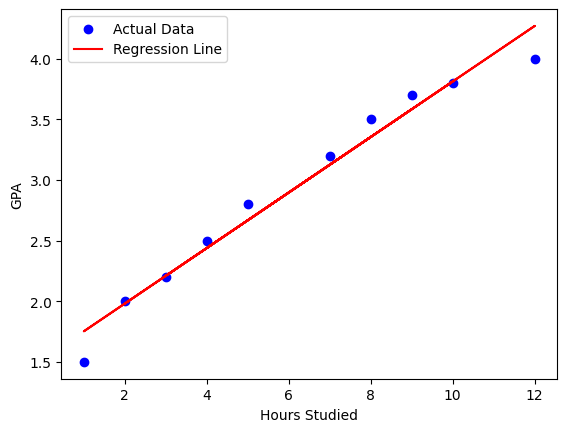

In [9]:
# Linear regression:
lr = LinearRegression()
lr.fit(X_reg, y_reg)

predicted_gpa = lr.predict([[6]])
print(f"Linear Reg: Predicted GPA for 6 study hours: {predicted_gpa[0]:.2f}")

plt.scatter(X_reg, y_reg, color='blue', label='Actual Data')
plt.plot(X_reg, lr.predict(X_reg), color='red', label='Regression Line')
plt.xlabel("Hours Studied")
plt.ylabel("GPA")
plt.legend()
plt.show()

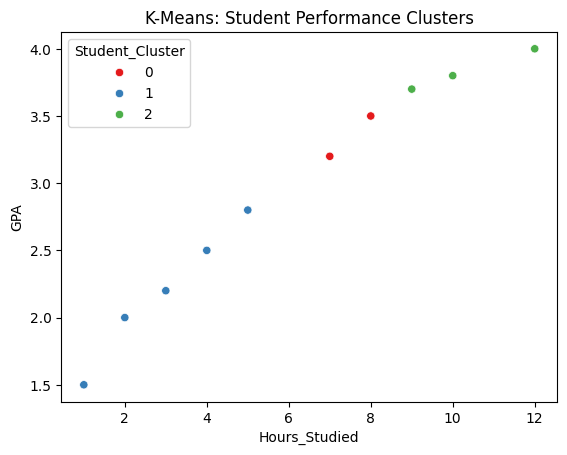

In [10]:
# K mean:
X_km = df[['Hours_Studied', 'GPA']]
kmeans = KMeans(n_clusters=3, random_state=42)
df['Student_Cluster'] = kmeans.fit_predict(X_km)

sns.scatterplot(x='Hours_Studied', y='GPA', hue='Student_Cluster', data=df, palette='Set1')
plt.title("K-Means: Student Performance Clusters")
plt.show()